In [ ]:
!pip install torchinfo

In [ ]:
# imports
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torchinfo import summary
import random

transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(root='./data', train =True, download = True, transform = transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = torchvision.datasets.MNIST(root='./data', train= False, download = True, transform = transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size= 64, shuffle= False)

print('importing completed...')

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 354kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.9MB/s]

importing completed...


In [ ]:
# Adding CNN
import torch.nn as nn

cnn_model = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Flatten(),
    nn.Linear(in_features=64*7*7, out_features=128),
    nn.ReLU(),
    nn.Linear(in_features=128, out_features=10)
)
print('Model understood...')

Model understood...


In [ ]:
# !pip uninstall torch torchvision torchaudio
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

In [ ]:
loss_fn = nn.CrossEntropyLoss()

cnn_optimizer = torch.optim.Adam(cnn_model.parameters(), lr = 0.001)
epochs = 5
print("Training in progres...")
for epoch in range(epochs):
  for images, label in train_loader:
    outputs = cnn_model(images)
    loss = loss_fn(outputs, label)
    cnn_optimizer.zero_grad()
    loss.backward()
    cnn_optimizer.step()
  print(f"Epoch {epoch + 1}/{epochs}")
print("Training Complete...")

Training in progres...
Epoch 1/5
Epoch 2/5
Epoch 3/5
Epoch 4/5
Epoch 5/5
Training Complete...


single test for reference...


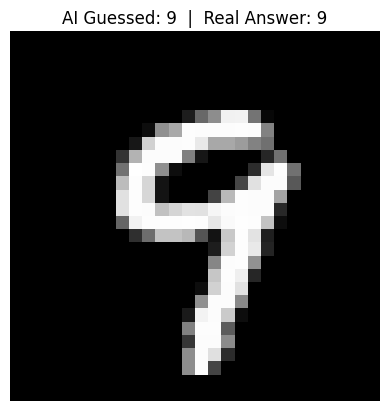

In [ ]:
idx =  random.randint(0, len(test_dataset)-1)
images, real_answer = test_dataset[idx]
with torch.no_grad():
  preds = cnn_model(images.unsqueeze(0))
answer = torch.argmax(preds).item()

print("single test for reference...")
plt.imshow(images.squeeze(),cmap='grey')
plt.title(f"AI Guessed: {answer}  |  Real Answer: {real_answer}")
plt.axis('off')
plt.show()

In [ ]:
cnn_model.eval()

correct_guesses = 0
total_images = 0

with torch.no_grad():
  for images, labels in test_loader:
    outputs = cnn_model(images)
    _, preds = torch.max(outputs, dim=1)


    total_images +=labels.size(0)
    correct_guesses += (preds == labels).sum().item()
cnn_accuracy = 100* correct_guesses/total_images

print(f"Final Score: The CNN guessed correctly {correct_guesses} out of {total_images} times.")
print(f"CNN Accuracy: {cnn_accuracy:.2f}%")

Final Score: The CNN guessed correctly 9870 out of 10000 times.
CNN Accuracy: 98.70%


In [ ]:
total_params = sum(p.numel() for p in cnn_model.parameters())
trainable_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)

print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

Total Parameters: 421,642
Trainable Parameters: 421,642


In [ ]:
summary(cnn_model, input_size=(1, 1, 28, 28), col_names=("input_size", "output_size", "num_params", "mult_adds"))

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Mult-Adds
Sequential                               [1, 1, 28, 28]            [1, 10]                   --                        --
├─Conv2d: 1-1                            [1, 1, 28, 28]            [1, 32, 28, 28]           320                       250,880
├─ReLU: 1-2                              [1, 32, 28, 28]           [1, 32, 28, 28]           --                        --
├─MaxPool2d: 1-3                         [1, 32, 28, 28]           [1, 32, 14, 14]           --                        --
├─Conv2d: 1-4                            [1, 32, 14, 14]           [1, 64, 14, 14]           18,496                    3,625,216
├─ReLU: 1-5                              [1, 64, 14, 14]           [1, 64, 14, 14]           --                        --
├─MaxPool2d: 1-6                         [1, 64, 14, 14]           [1, 64, 7, 7]             --                        --
├─Fla